P2.Q1

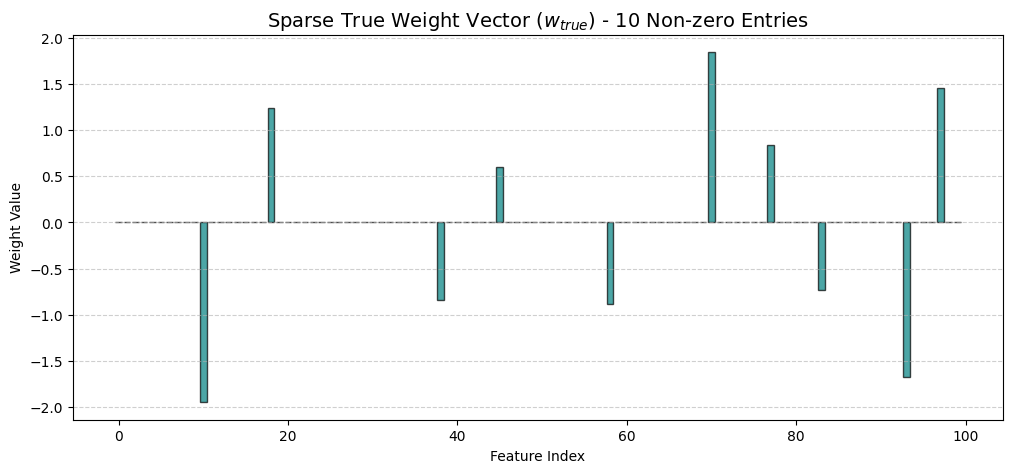

In [255]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# dimensions
n = 50
d = 100
k = 10  

X = np.random.normal(0, 1, size=(n, d))

w_true = np.zeros(d)
non_zero_indices = np.random.choice(d, k, replace=False)
w_true[non_zero_indices] = np.random.normal(0, np.sqrt(5), size=k)

# generate noise epsilon 

eps_std = .5
epsilon = np.random.normal(0, eps_std, size=n)

# generate y
y = X @ w_true + epsilon

# Plotting
plt.figure(figsize=(12, 5))
plt.bar(range(d), w_true, color='teal', edgecolor='black', alpha=0.7)
plt.title(f"Sparse True Weight Vector ($w_{{true}}$) - {k} Non-zero Entries", fontsize=14)
plt.xlabel("Feature Index")
plt.ylabel("Weight Value")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

P2.Q2

In [256]:
import numpy as np
import matplotlib.pyplot as plt



# center
X_mean = np.mean(X, axis=0)
y_mean = np.mean(y)
X_centered = X - X_mean
y_centered = y - y_mean

# closed form
# w_ridge = (X^T X + λI)^-1 X^T y

lmbda = 1.0
I = np.eye(d)
w_ridge = np.linalg.inv(X_centered.T @ X_centered + lmbda * I) @ X_centered.T @ y_centered

y_pred_centered = X_centered @ w_ridge



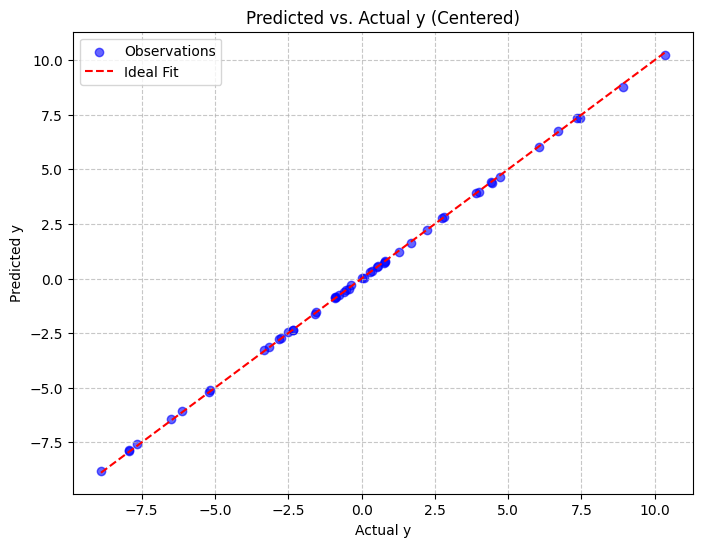

In [257]:
plt.figure(figsize=(8, 6))
plt.scatter(y_centered, y_pred_centered, color='blue', alpha=0.6, label='Observations')
plt.plot([y_centered.min(), y_centered.max()], [y_centered.min(), y_centered.max()], 'r--', label='Ideal Fit')
plt.title('Predicted vs. Actual y (Centered)')
plt.xlabel('Actual y')
plt.ylabel('Predicted y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)


<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Ian\AppData\Local\Temp\ipykernel_29596\2156376713.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.title('Weight Comparison: $w_{true}$ vs $w_{ridge}$ ($\lambda=1$)')


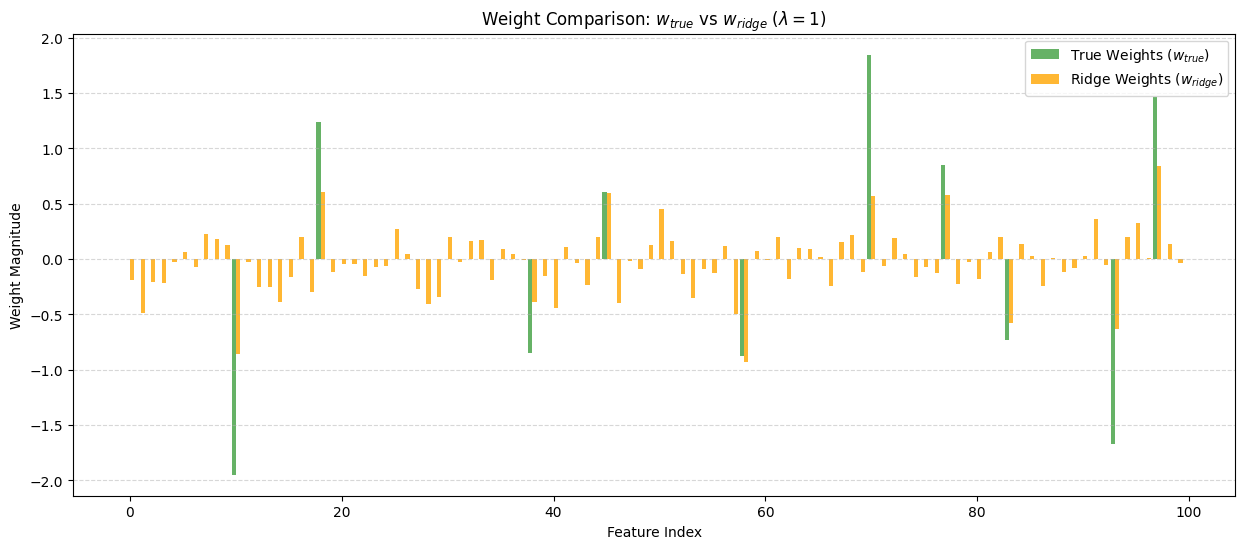

In [258]:
plt.figure(figsize=(15, 6))
indices = np.arange(100)
width = 0.4
plt.bar(indices - width/2, w_true, width, label='True Weights ($w_{true}$)', color='green', alpha=0.6)
plt.bar(indices + width/2, w_ridge, width, label='Ridge Weights ($w_{ridge}$)', color='orange', alpha=0.8)
plt.title('Weight Comparison: $w_{true}$ vs $w_{ridge}$ ($\lambda=1$)')
plt.xlabel('Feature Index')
plt.ylabel('Weight Magnitude')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)


there exists a good correlation between pred and actual. regularization helps prevent overfitting. it does shrink nonzero weights. there are also no exact zeros. 

P2.Q3a

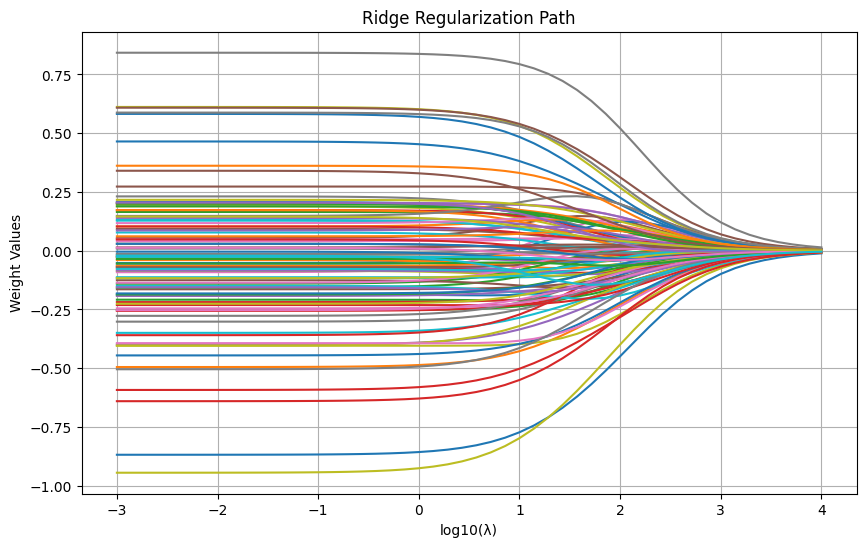

In [259]:
lambdas = np.logspace(-3, 4, 50)
weights_path = []
I = np.eye(d)
for lmbda in lambdas:
    w_ridge = np.linalg.inv(X_centered.T @ X_centered + lmbda * I) @ X_centered.T @ y_centered
    weights_path.append(w_ridge)

weights_path = np.array(weights_path)

plt.figure(figsize=(10, 6))
plt.plot(np.log10(lambdas), weights_path)
plt.title('Ridge Regularization Path')
plt.xlabel('log10(λ)')
plt.ylabel('Weight Values')
plt.grid(True)
plt.savefig('ridge_regularization_path.png')

as $\lambda$ grows, the weights converge.

<>:41: SyntaxWarning: invalid escape sequence '\l'
<>:41: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Ian\AppData\Local\Temp\ipykernel_29596\3144364458.py:41: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\log_{10}(\lambda)$', fontsize=12)


Optimal lambda (min test MSE): 0.0010
log10(Optimal lambda): -3.0000


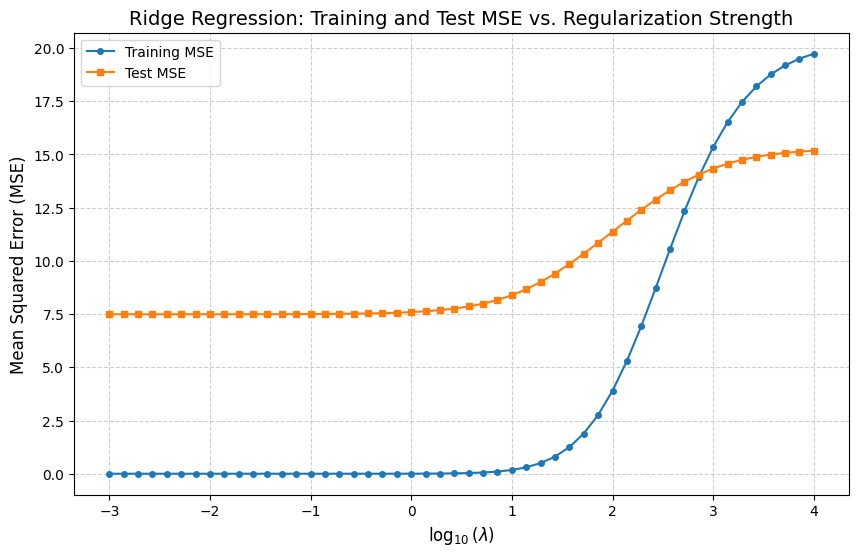

In [260]:
indices = np.arange(n)
np.random.shuffle(indices)
train_idx = indices[:int(0.8 * n)]
test_idx = indices[int(0.8 * n):]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

train_mse = []
test_mse = []

for lmbda in lambdas:
    #center
    X_train_mean = np.mean(X_train, axis=0)
    y_train_mean = np.mean(y_train)
    X_train_c = X_train - X_train_mean
    y_train_c = y_train - y_train_mean
    X_test_c = X_test - X_train_mean
    y_test_c = y_test - y_train_mean
    

    XTX = X_train_c.T @ X_train_c
    XTy = X_train_c.T @ y_train_c
    w_ridge = np.linalg.inv(XTX + lmbda * I) @ XTy
    
    y_train_pred = X_train_c @ w_ridge
    y_test_pred = X_test_c @ w_ridge
    
    # MSE Calculations
    mse_tr = np.mean((y_train_c - y_train_pred)**2)
    mse_te = np.mean((y_test_c - y_test_pred)**2)
    
    train_mse.append(mse_tr)
    test_mse.append(mse_te)
    
# Plotting MSE vs log10(lambda)
plt.figure(figsize=(10, 6))
plt.plot(np.log10(lambdas), train_mse, label='Training MSE', marker='o', markersize=4)
plt.plot(np.log10(lambdas), test_mse, label='Test MSE', marker='s', markersize=4)
plt.title('Ridge Regression: Training and Test MSE vs. Regularization Strength', fontsize=14)
plt.xlabel('$\log_{10}(\lambda)$', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('mse_vs_lambda.png')

# Find optimal lambda for context
opt_lambda = lambdas[np.argmin(test_mse)]
print(f"Optimal lambda (min test MSE): {opt_lambda:.4f}")
print(f"log10(Optimal lambda): {np.log10(opt_lambda):.4f}")

yes, mse does increase monotonically w $\lambda$. 

i do not see the behavior of mse decreasing then increasing. 

if i up epsilon, i do see the dip.

the optimal is closer to 10^4 after i increase epsilon to 10.

P3.Q1b

In [261]:
def ridge_gradient_descent(X, y, alpha, lmbda, iterations=1000):
    """
    X: Feature matrix (n_samples, n_features)
    y: Target vector (n_samples, 1)
    alpha: Learning rate
    lmbda: Regularization parameter
    """
    n_samples, n_features = X.shape
    w = np.zeros((n_features, 1))
    loss_history = []

    for i in range(iterations):
        predictions = X @ w
        
        # J(w) = (Xw - y)^T (Xw - y) + λ w^T w
        error = predictions - y
        loss = (error.T @ error) + lmbda * (w.T @ w)
        loss_history.append(loss.flatten()[0])
        
        # grad = 2X^T(Xw - y) + 2λw
        gradient = 2 * (X.T @ error) + 2 * lmbda * w
        
        w = w - alpha * gradient
        
    return w, loss_history

def plot3(losses, iters,alpha):
    plt.plot(range(iters), losses, color='blue', linewidth=2)
    plt.xlabel('Iterations')
    plt.ylabel('Loss $J(w)$')
    plt.title(f'Ridge Regression Gradient Descent Convergence, alpha = {alpha}')
    plt.grid(True, linestyle='--', alpha=0.7)
    # plt.savefig('ridge_loss_plot.png')

def weight_comparison(weights):
    plt.figure(figsize=(15, 6))
    indices = np.arange(100)
    width = 0.4
    plt.bar(indices - width/2, w_true, width, label='True Weights ($w_{true}$)', color='green', alpha=0.6)
    plt.bar(indices + width/2, weights, width, label='Grad Descent Weights ($w_{ridge}$)', color='orange', alpha=0.8)
    plt.title('Weight Comparison: $w_{true}$ vs weights')
    plt.xlabel('Feature Index')
    plt.ylabel('Weight Magnitude')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)

In [262]:
alpha1 = [0.0001,0.001,0.01]

weight diff: 4.106559339830438


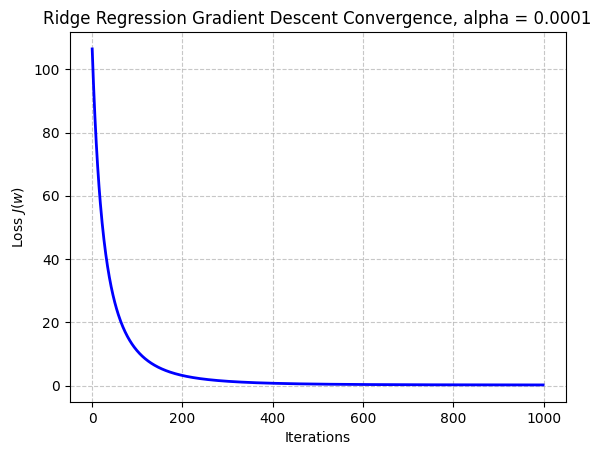

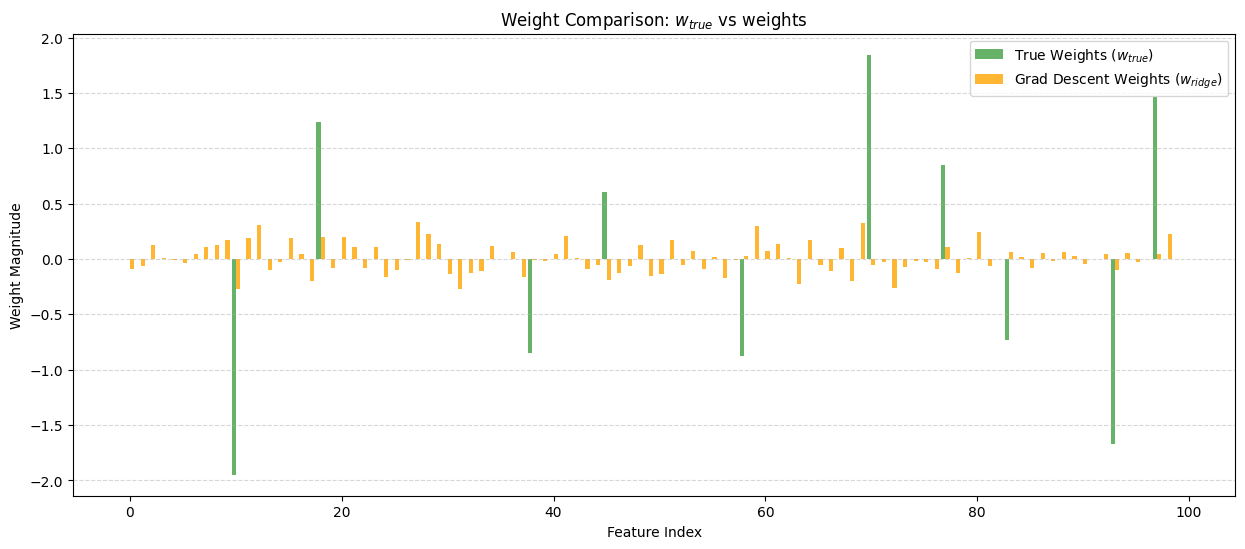

weight diff: 4.108756394526143


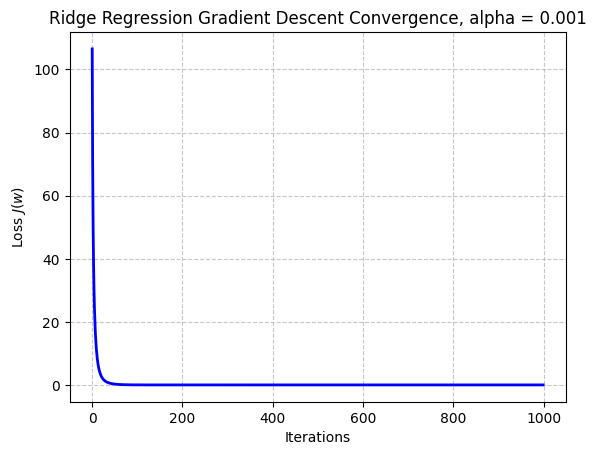

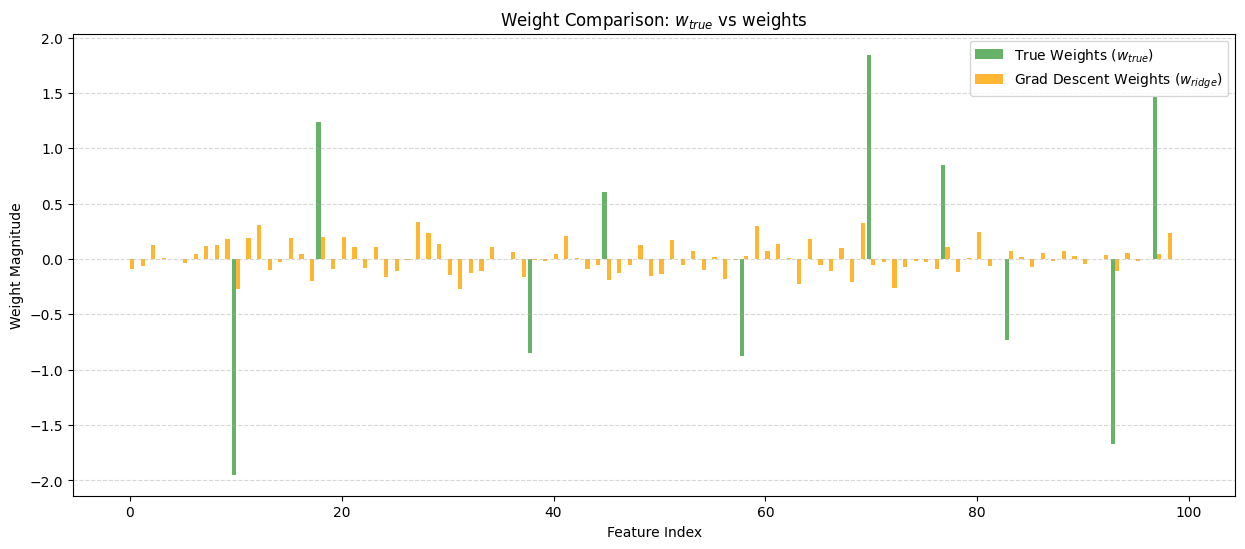

weight diff: nan


C:\Users\Ian\AppData\Local\Temp\ipykernel_29596\1241878988.py:17: RuntimeWarning: overflow encountered in matmul
  loss = (error.T @ error) + lmbda * (w.T @ w)
C:\Users\Ian\AppData\Local\Temp\ipykernel_29596\1241878988.py:17: RuntimeWarning: overflow encountered in add
  loss = (error.T @ error) + lmbda * (w.T @ w)
C:\Users\Ian\AppData\Local\Temp\ipykernel_29596\1241878988.py:21: RuntimeWarning: overflow encountered in multiply
  gradient = 2 * (X.T @ error) + 2 * lmbda * w
C:\Users\Ian\AppData\Local\Temp\ipykernel_29596\1241878988.py:13: RuntimeWarning: invalid value encountered in matmul
  predictions = X @ w
C:\Users\Ian\AppData\Local\Temp\ipykernel_29596\1241878988.py:17: RuntimeWarning: invalid value encountered in matmul
  loss = (error.T @ error) + lmbda * (w.T @ w)
C:\Users\Ian\AppData\Local\Temp\ipykernel_29596\1241878988.py:21: RuntimeWarning: overflow encountered in matmul
  gradient = 2 * (X.T @ error) + 2 * lmbda * w
C:\Users\Ian\AppData\Local\Temp\ipykernel_29596\12418789

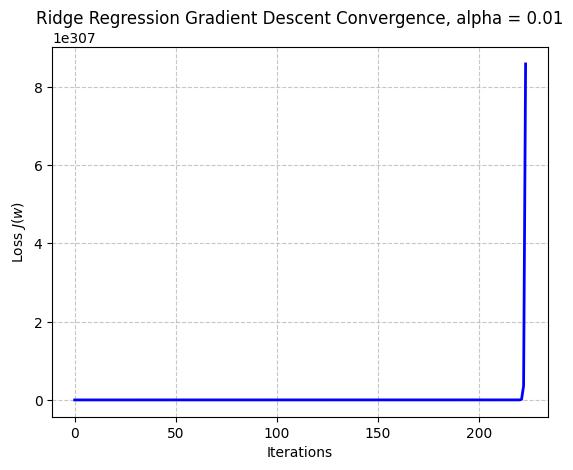

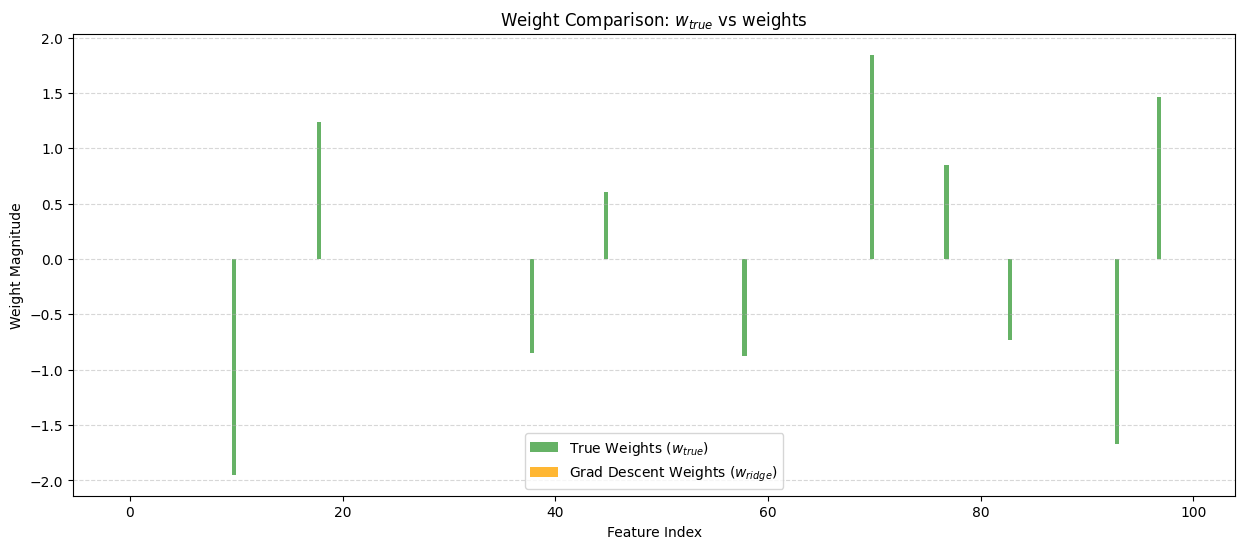

In [263]:

for i in range(len(alpha1)):
    alpha_post_grad_descent_weights,alpha_post_grad_descent_losses = ridge_gradient_descent(X, y, alpha=alpha1[i], lmbda=0.1, iterations=1000)
    final_weights = alpha_post_grad_descent_weights[:, 0]
    print(f"weight diff: {np.linalg.norm(final_weights - w_true)}")
    plot3(alpha_post_grad_descent_losses, len(alpha_post_grad_descent_losses),alpha1[i])
    plt.show()
    
    weight_comparison(final_weights)
    plt.show()

    
    
